# CNN vs Vision Transformer Model Comparison

This notebook compares the final DenseNet121 CNN and ViT-B/16 models on the same RSNA test set. It uses saved predictions and metrics only; no model retraining or GPU is required.


In [ ]:
from pathlib import Path
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    balanced_accuracy_score,
    brier_score_loss,
    confusion_matrix,
    f1_score,
    matthews_corrcoef,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)

pd.set_option("display.max_columns", None)

# ============================================================
# PATHS
# ============================================================

PROJECT_DIR = Path("...").resolve()

RESULTS_DIR = PROJECT_DIR / "results"

CNN_DIR = RESULTS_DIR / "cnn"
VIT_DIR = RESULTS_DIR / "vit"
COMPARISON_DIR = RESULTS_DIR / "comparison"

COMPARISON_DIR.mkdir(parents=True, exist_ok=True)

# Model result files
cnn_predictions_path = CNN_DIR / "predictions" / "test_predictions.csv"
vit_predictions_path = VIT_DIR / "predictions" / "test_predictions.csv"

cnn_metrics_path = CNN_DIR / "metrics" / "test_metrics.csv"
vit_metrics_path = VIT_DIR / "metrics" / "test_metrics.csv"

# Verify required files
required_files = {
    "CNN predictions": cnn_predictions_path,
    "ViT predictions": vit_predictions_path,
    "CNN metrics": cnn_metrics_path,
    "ViT metrics": vit_metrics_path,
}

assert all(path.exists() for path in required_files.values()), (
    "One or more required result files were not found."
)

## 1. Load and Validate Test Predictions


In [2]:
cnn_pred = pd.read_csv(cnn_predictions_path)
vit_pred = pd.read_csv(vit_predictions_path)

print("CNN prediction columns:", cnn_pred.columns.tolist())
print("ViT prediction columns:", vit_pred.columns.tolist())
print("CNN rows:", len(cnn_pred))
print("ViT rows:", len(vit_pred))


CNN prediction columns: ['patientId', 'target', 'probability', 'prediction', 'detailed_class', 'num_pneumonia_boxes', 'error_type']
ViT prediction columns: ['patientId', 'target', 'probability', 'prediction', 'detailed_class', 'num_pneumonia_boxes', 'error_type']
CNN rows: 4003
ViT rows: 4003


In [3]:
def standardize_predictions(df, model_name):
    df = df.copy()

    aliases = {
        "patientId": ["patientId", "patient_id", "patientid"],
        "true_label": ["true_label", "target", "label", "y_true"],
        "predicted_probability": [
            "predicted_probability", "probability", "pred_prob", "y_prob", "prob"
        ],
        "prediction": ["prediction", "predicted_label", "y_pred"],
    }

    rename = {}
    for canonical, options in aliases.items():
        match = next((c for c in options if c in df.columns), None)
        if match is not None:
            rename[match] = canonical
    df = df.rename(columns=rename)

    required = {"patientId", "true_label", "predicted_probability"}
    missing = required - set(df.columns)
    if missing:
        raise ValueError(f"{model_name}: missing required columns {sorted(missing)}")

    return df

cnn_pred = standardize_predictions(cnn_pred, "CNN")
vit_pred = standardize_predictions(vit_pred, "ViT")

if cnn_pred["patientId"].duplicated().any() or vit_pred["patientId"].duplicated().any():
    raise ValueError("Duplicate patient IDs found in test predictions.")

cnn_ids = set(cnn_pred["patientId"])
vit_ids = set(vit_pred["patientId"])

print("Same test patient set:", cnn_ids == vit_ids)
print("CNN test patients:", len(cnn_ids))
print("ViT test patients:", len(vit_ids))

if cnn_ids != vit_ids:
    raise ValueError("CNN and ViT predictions do not contain the same test patients.")

paired = cnn_pred[["patientId", "true_label", "predicted_probability"]].merge(
    vit_pred[["patientId", "true_label", "predicted_probability"]],
    on="patientId",
    suffixes=("_cnn", "_vit"),
    validate="one_to_one",
)

if not np.array_equal(paired["true_label_cnn"].to_numpy(), paired["true_label_vit"].to_numpy()):
    raise ValueError("Ground-truth labels differ between CNN and ViT prediction files.")

print("Ground-truth labels match: True")


Same test patient set: True
CNN test patients: 4003
ViT test patients: 4003
Ground-truth labels match: True


## 2. Load Selected Decision Thresholds


In [5]:
def load_threshold(model_dir, predictions):
    threshold_path = model_dir / "analysis" / "selected_threshold.json"

    if threshold_path.exists():
        with open(threshold_path, "r", encoding="utf-8") as f:
            obj = json.load(f)

        # Handle common JSON formats
        if isinstance(obj, dict):
            for key in ["threshold", "selected_threshold", "best_threshold"]:
                if key in obj:
                    return float(obj[key])

        elif isinstance(obj, (int, float)):
            return float(obj)

    # Fallback: check whether threshold is stored in predictions
    for column in ["threshold", "selected_threshold"]:
        if column in predictions.columns:
            values = predictions[column].dropna().unique()

            if len(values) > 0:
                return float(values[0])

    raise ValueError(
        f"Could not determine the validation-selected threshold for {model_dir.name}."
    )


cnn_threshold = load_threshold(CNN_DIR, cnn_pred)
vit_threshold = load_threshold(VIT_DIR, vit_pred)

print(f"CNN threshold: {cnn_threshold:.2f}")
print(f"ViT threshold: {vit_threshold:.2f}")

CNN threshold: 0.60
ViT threshold: 0.57


## 3. Recalculate Test Metrics

Metrics are recalculated from the saved patient-level predictions so both models are compared using exactly the same definitions.


In [6]:
def calculate_metrics(df, threshold):
    y_true = df["true_label"].astype(int).to_numpy()
    y_prob = df["predicted_probability"].astype(float).to_numpy()
    y_pred = (y_prob >= threshold).astype(int)

    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    specificity = tn / (tn + fp)
    npv = tn / (tn + fn)

    return {
        "ROC-AUC": roc_auc_score(y_true, y_prob),
        "PR-AUC": average_precision_score(y_true, y_prob),
        "Accuracy": accuracy_score(y_true, y_pred),
        "Balanced Accuracy": balanced_accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall / Sensitivity": recall_score(y_true, y_pred, zero_division=0),
        "Specificity": specificity,
        "NPV": npv,
        "F1": f1_score(y_true, y_pred, zero_division=0),
        "MCC": matthews_corrcoef(y_true, y_pred),
        "Brier Score": brier_score_loss(y_true, y_prob),
        "TN": int(tn),
        "FP": int(fp),
        "FN": int(fn),
        "TP": int(tp),
        "Threshold": threshold,
    }

cnn_metrics = calculate_metrics(cnn_pred, cnn_threshold)
vit_metrics = calculate_metrics(vit_pred, vit_threshold)

comparison = pd.DataFrame({"CNN (DenseNet121)": cnn_metrics, "ViT-B/16": vit_metrics})
comparison.index.name = "Metric"
comparison


,CNN (DenseNet121),ViT-B/16
Metric,,
ROC-AUC,0.881840,0.885048
PR-AUC,0.700388,0.698398
Accuracy,0.827130,0.811891
Balanced Accuracy,0.790152,0.799970
Precision,0.595978,0.559363
Recall / Sensitivity,0.722838,0.778271
Specificity,0.857465,0.821670
NPV,0.914060,0.927220
F1,0.653307,0.650904


In [ ]:
comparison.to_csv(COMPARISON_DIR / "cnn_vit_test_metrics_comparison.csv")

report_metrics = [
    "ROC-AUC", "PR-AUC", "Accuracy", "Balanced Accuracy", "Precision",
    "Recall / Sensitivity", "Specificity", "NPV", "F1", "MCC", "Brier Score"
]
comparison.loc[report_metrics].round(4)


## 4. ROC Curve Comparison


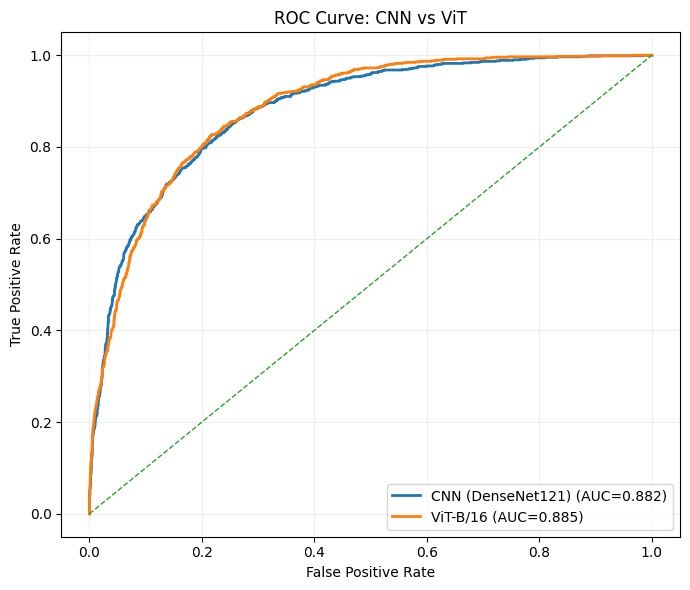

In [7]:
plt.figure(figsize=(7, 6))
for name, df in [("CNN (DenseNet121)", cnn_pred), ("ViT-B/16", vit_pred)]:
    y_true = df["true_label"].to_numpy()
    y_prob = df["predicted_probability"].to_numpy()
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    auc = roc_auc_score(y_true, y_prob)
    plt.plot(fpr, tpr, linewidth=2, label=f"{name} (AUC={auc:.3f})")

plt.plot([0, 1], [0, 1], linestyle="--", linewidth=1)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve: CNN vs ViT")
plt.legend()
plt.grid(alpha=0.2)
plt.tight_layout()
plt.savefig(COMPARISON_DIR / "cnn_vit_roc_curve.png", dpi=200, bbox_inches="tight")
plt.show()


## 5. Precision-Recall Curve Comparison


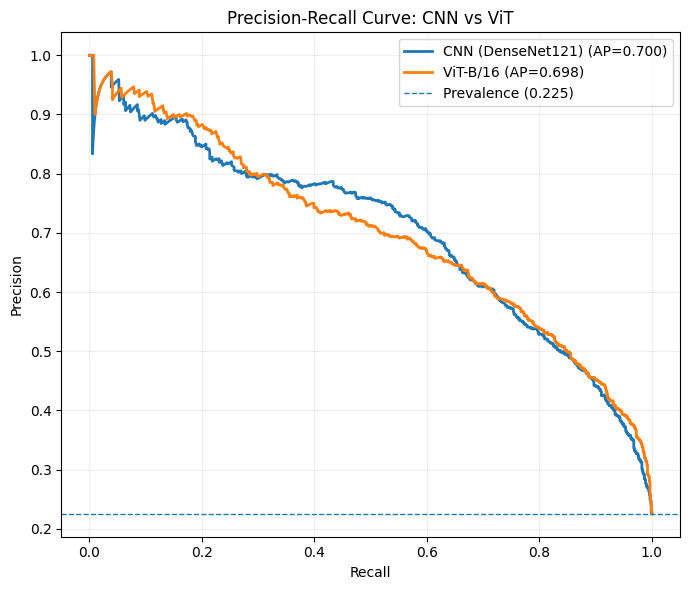

In [8]:
plt.figure(figsize=(7, 6))
for name, df in [("CNN (DenseNet121)", cnn_pred), ("ViT-B/16", vit_pred)]:
    y_true = df["true_label"].to_numpy()
    y_prob = df["predicted_probability"].to_numpy()
    precision, recall, _ = precision_recall_curve(y_true, y_prob)
    ap = average_precision_score(y_true, y_prob)
    plt.plot(recall, precision, linewidth=2, label=f"{name} (AP={ap:.3f})")

prevalence = cnn_pred["true_label"].mean()
plt.axhline(prevalence, linestyle="--", linewidth=1, label=f"Prevalence ({prevalence:.3f})")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve: CNN vs ViT")
plt.legend()
plt.grid(alpha=0.2)
plt.tight_layout()
plt.savefig(COMPARISON_DIR / "cnn_vit_precision_recall_curve.png", dpi=200, bbox_inches="tight")
plt.show()


## 6. Operating-Point Metric Comparison


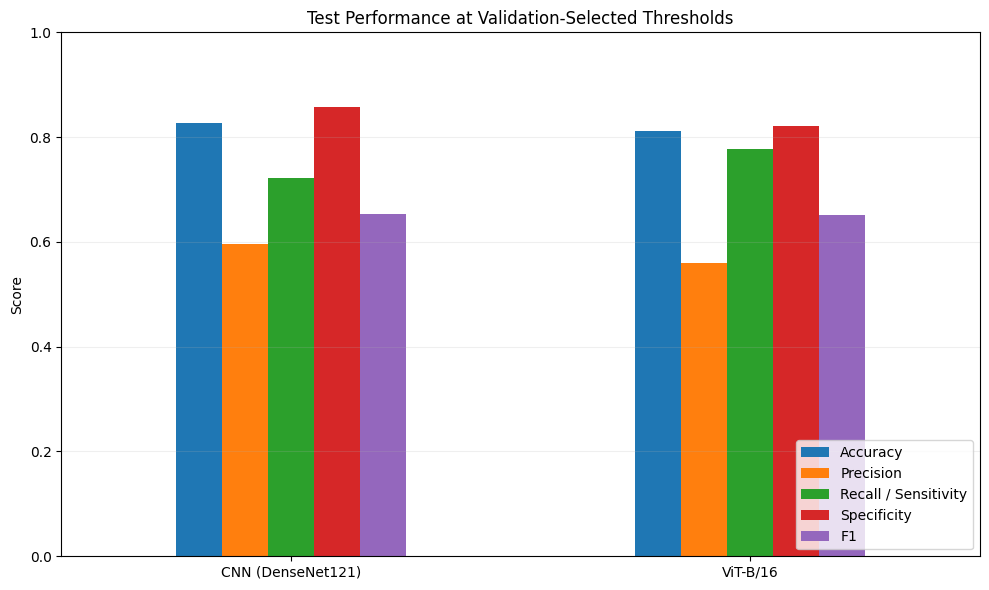

In [9]:
plot_metrics = ["Accuracy", "Precision", "Recall / Sensitivity", "Specificity", "F1"]
plot_df = comparison.loc[plot_metrics].T

ax = plot_df.plot(kind="bar", figsize=(10, 6))
ax.set_ylim(0, 1)
ax.set_ylabel("Score")
ax.set_title("Test Performance at Validation-Selected Thresholds")
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
ax.legend(loc="lower right")
ax.grid(axis="y", alpha=0.2)
plt.tight_layout()
plt.savefig(COMPARISON_DIR / "cnn_vit_operating_metrics.png", dpi=200, bbox_inches="tight")
plt.show()


## 7. Confusion Matrices


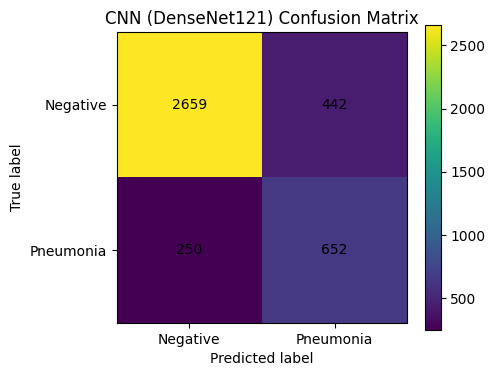

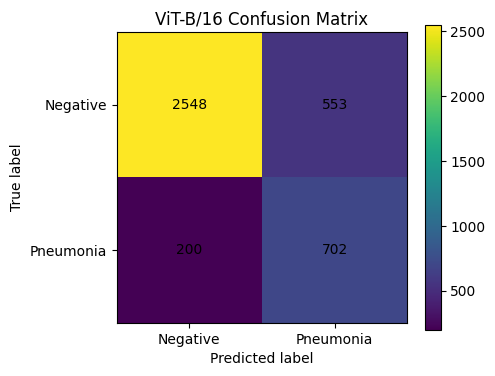

In [10]:
for name, df, threshold, filename in [
    ("CNN (DenseNet121)", cnn_pred, cnn_threshold, "cnn_confusion_matrix.png"),
    ("ViT-B/16", vit_pred, vit_threshold, "vit_confusion_matrix.png"),
]:
    y_true = df["true_label"].astype(int).to_numpy()
    y_pred = (df["predicted_probability"].to_numpy() >= threshold).astype(int)
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])

    fig, ax = plt.subplots(figsize=(5, 4))
    image = ax.imshow(cm)
    for i in range(2):
        for j in range(2):
            ax.text(j, i, str(cm[i, j]), ha="center", va="center")
    ax.set_xticks([0, 1], labels=["Negative", "Pneumonia"])
    ax.set_yticks([0, 1], labels=["Negative", "Pneumonia"])
    ax.set_xlabel("Predicted label")
    ax.set_ylabel("True label")
    ax.set_title(f"{name} Confusion Matrix")
    fig.colorbar(image, ax=ax)
    plt.tight_layout()
    plt.savefig(COMPARISON_DIR / filename, dpi=200, bbox_inches="tight")
    plt.show()


## 8. Diagnostic-Class Error Comparison

This analysis is included when the saved prediction files contain `detailed_class`. It distinguishes pneumonia, abnormal non-pneumonia, and normal radiographs.


,detailed_class,samples,errors,error_rate,model
0,Lung Opacity,902,250,0.2772,CNN (DenseNet121)
1,No Lung Opacity / Not Normal,1780,435,0.2444,CNN (DenseNet121)
2,Normal,1321,7,0.0053,CNN (DenseNet121)
3,Lung Opacity,902,200,0.2217,ViT-B/16
4,No Lung Opacity / Not Normal,1780,544,0.3056,ViT-B/16
5,Normal,1321,9,0.0068,ViT-B/16


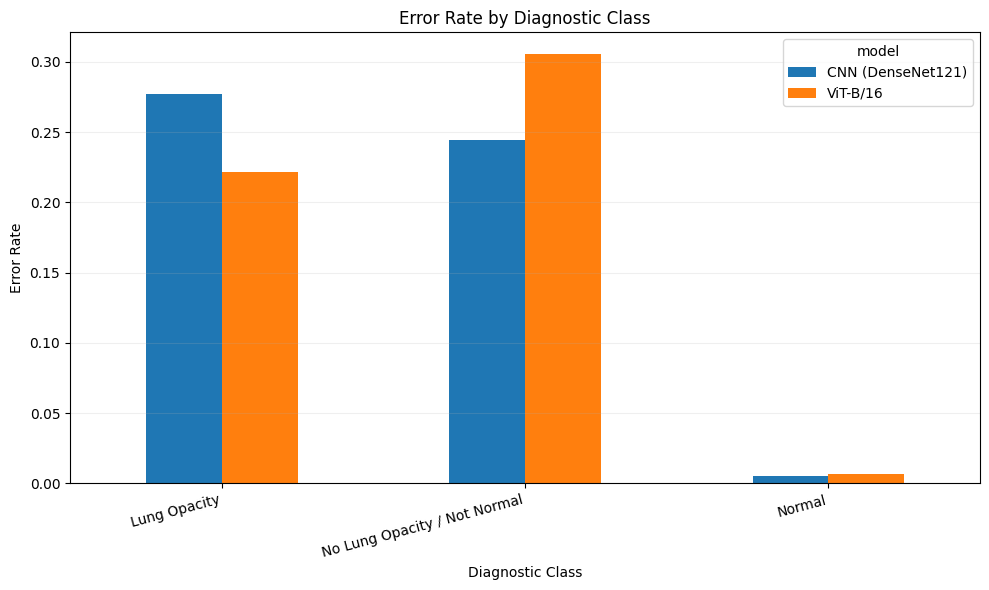

In [11]:
def subgroup_errors(df, threshold, model_name):
    if "detailed_class" not in df.columns:
        return None

    temp = df.copy()
    temp["prediction"] = (temp["predicted_probability"] >= threshold).astype(int)
    temp["error"] = (temp["prediction"] != temp["true_label"]).astype(int)

    summary = (
        temp.groupby("detailed_class", as_index=False)
        .agg(samples=("patientId", "size"), errors=("error", "sum"), error_rate=("error", "mean"))
    )
    summary["model"] = model_name
    return summary

cnn_subgroup = subgroup_errors(cnn_pred, cnn_threshold, "CNN (DenseNet121)")
vit_subgroup = subgroup_errors(vit_pred, vit_threshold, "ViT-B/16")

if cnn_subgroup is not None and vit_subgroup is not None:
    subgroup_comparison = pd.concat([cnn_subgroup, vit_subgroup], ignore_index=True)
    subgroup_comparison.to_csv(COMPARISON_DIR / "cnn_vit_subgroup_error_comparison.csv", index=False)
    display(subgroup_comparison.round(4))

    pivot = subgroup_comparison.pivot(index="detailed_class", columns="model", values="error_rate")
    ax = pivot.plot(kind="bar", figsize=(10, 6))
    ax.set_ylabel("Error Rate")
    ax.set_xlabel("Diagnostic Class")
    ax.set_title("Error Rate by Diagnostic Class")
    ax.set_xticklabels(ax.get_xticklabels(), rotation=15, ha="right")
    ax.grid(axis="y", alpha=0.2)
    plt.tight_layout()
    plt.savefig(COMPARISON_DIR / "cnn_vit_subgroup_error_rates.png", dpi=200, bbox_inches="tight")
    plt.show()
else:
    print("Skipped: detailed_class is not present in both test prediction files.")


## 9. Paired Prediction Agreement


In [13]:
paired["cnn_prediction"] = (paired["predicted_probability_cnn"] >= cnn_threshold).astype(int)
paired["vit_prediction"] = (paired["predicted_probability_vit"] >= vit_threshold).astype(int)
paired["models_agree"] = paired["cnn_prediction"] == paired["vit_prediction"]
paired["cnn_correct"] = paired["cnn_prediction"] == paired["true_label_cnn"]
paired["vit_correct"] = paired["vit_prediction"] == paired["true_label_cnn"]

agreement_summary = pd.DataFrame({
    "metric": [
        "prediction_agreement_rate",
        "both_correct",
        "cnn_only_correct",
        "vit_only_correct",
        "both_incorrect",
    ],
    "value": [
        paired["models_agree"].mean(),
        (paired["cnn_correct"] & paired["vit_correct"]).mean(),
        (paired["cnn_correct"] & ~paired["vit_correct"]).mean(),
        (~paired["cnn_correct"] & paired["vit_correct"]).mean(),
        (~paired["cnn_correct"] & ~paired["vit_correct"]).mean(),
    ],
})

agreement_summary.to_csv(COMPARISON_DIR / "cnn_vit_prediction_agreement.csv", index=False)
agreement_summary.round(4)


,metric,value
0,prediction_agreement_rate,0.9043
1,both_correct,0.7717
2,cnn_only_correct,0.0555
3,vit_only_correct,0.0402
4,both_incorrect,0.1327


## 10. Comparison Summary


In [14]:
summary_rows = []
for metric in ["ROC-AUC", "PR-AUC", "Accuracy", "Precision", "Recall / Sensitivity", "Specificity", "F1", "MCC", "Brier Score"]:
    summary_rows.append({
        "metric": metric,
        "cnn": cnn_metrics[metric],
        "vit": vit_metrics[metric],
        "difference_cnn_minus_vit": cnn_metrics[metric] - vit_metrics[metric],
    })

summary_df = pd.DataFrame(summary_rows)
summary_df.to_csv(COMPARISON_DIR / "cnn_vit_summary.csv", index=False)
summary_df.round(4)


,metric,cnn,vit,difference_cnn_minus_vit
0,ROC-AUC,0.8818,0.8850,-0.0032
1,PR-AUC,0.7004,0.6984,0.0020
2,Accuracy,0.8271,0.8119,0.0152
3,Precision,0.5960,0.5594,0.0366
4,Recall / Sensitivity,0.7228,0.7783,-0.0554
5,Specificity,0.8575,0.8217,0.0358
6,F1,0.6533,0.6509,0.0024
7,MCC,0.5440,0.5403,0.0037
8,Brier Score,0.1466,0.1460,0.0006


### Interpretation

Use the generated tables and figures to describe the comparison rather than choosing a model from a single metric. ROC-AUC and PR-AUC summarize ranking performance across thresholds, while precision, sensitivity, specificity and F1 describe performance at each model's validation-selected operating threshold. The subgroup analysis shows whether errors are concentrated in pneumonia, abnormal non-pneumonia, or normal radiographs. Grad-CAM from the CNN pipeline and self-attention maps from the ViT pipeline provide complementary qualitative views of model focus.

Because the two models are evaluated on the same patients, their errors can also be compared directly using the paired prediction agreement table.


## 11. Saved Comparison Artifacts


In [15]:
saved_files = sorted(p.name for p in COMPARISON_DIR.iterdir() if p.is_file())
print("Artifacts saved under:", COMPARISON_DIR)
for name in saved_files:
    print("-", name)


Artifacts saved under: E:\GitHub\pneumonia-classification-cnn-vit\results\comparison
- cnn_confusion_matrix.png
- cnn_vit_operating_metrics.png
- cnn_vit_precision_recall_curve.png
- cnn_vit_prediction_agreement.csv
- cnn_vit_roc_curve.png
- cnn_vit_subgroup_error_comparison.csv
- cnn_vit_subgroup_error_rates.png
- cnn_vit_summary.csv
- vit_confusion_matrix.png
